# FR5 策略测试输出分析

这个 notebook 专门读取 `fr5_policy_rollout.py` 生成的测试日志：

```text
demo/fr5_demo/data/policy_rollouts/**/*.npz
demo/fr5_demo/data/policy_rollouts/**/*.json
```

用于观察策略是否被动作限幅、仿真关节是否跟得上、TCP 是否异常下坠，以及 `--sim-task-rollout` 的闭环任务是否成功。

## 0. 先生成一条测试日志

在终端运行：

```bash
cd ~/gs_playground
uv run python demo/fr5_demo/fr5_policy_rollout.py \
  --policy demo/fr5_demo/data/il_policies/fr5_bc_last.pt \
  --sim-task-rollout \
  --max-steps 100 \
  --hz 10 \
  --log-every 1
```

如果只想后台跑，加 `--no-window`。

In [45]:
from pathlib import Path
import json

import numpy as np
import matplotlib.pyplot as plt

ROOT = Path.cwd()
if not (ROOT / 'demo/fr5_demo').exists():
    ROOT = Path('../../..').resolve()

ROLLOUT_DIR = ROOT / 'demo/fr5_demo/data/policy_rollouts'

# 手动指定要分析的 rollout。留空则自动选择全部目录中最新的 sim-task 日志。
# 可以写目录：'batch_eval/thesis_eval_ablation_v1'
# 也可以写单个 .npz 文件：'batch_eval/.../simtask_xxx.npz'
SELECTED_ROLLOUT = 'batch_eval/thesis_eval_ablation_v1'

REQUIRED_KEYS = {'pred_action_raw', 'pred_action_clipped', 'action_clipped_mask', 'q_error_target_minus_sim', 'tcp_sim'}

def rel(path: Path):
    try:
        return path.resolve().relative_to(ROOT)
    except Exception:
        return path

def resolve_rollout_selector(selector: str):
    selector = str(selector or '').strip()
    if not selector:
        return None
    path = Path(selector).expanduser()
    if not path.is_absolute():
        by_rollout_dir = ROLLOUT_DIR / path
        by_root = ROOT / path
        path = by_rollout_dir if by_rollout_dir.exists() else by_root
    path = path.resolve()
    if not path.exists():
        raise FileNotFoundError(f'SELECTED_ROLLOUT does not exist: {path}')
    return path

selected_root = resolve_rollout_selector(SELECTED_ROLLOUT)
if selected_root is None:
    search_root = ROLLOUT_DIR
    all_logs = sorted(ROLLOUT_DIR.glob('**/*.npz'), key=lambda p: p.stat().st_mtime)
elif selected_root.is_dir():
    search_root = selected_root
    all_logs = sorted(selected_root.glob('**/*.npz'), key=lambda p: p.stat().st_mtime)
else:
    search_root = selected_root.parent
    all_logs = [selected_root]

def is_new_rollout_log(path: Path):
    try:
        data = np.load(path, allow_pickle=True)
        return REQUIRED_KEYS.issubset(set(data.files))
    except Exception:
        return False

def load_meta(path: Path):
    meta_path = path.with_suffix('.json')
    return json.loads(meta_path.read_text(encoding='utf-8')) if meta_path.exists() else {}

def is_simtask_log(path: Path):
    meta = load_meta(path)
    if meta.get('sim_task_rollout') is True:
        return True
    mode = str(meta.get('mode', ''))
    return path.name.startswith('simtask_') or mode.startswith('sim-task')

logs = [p for p in all_logs if is_new_rollout_log(p)]
simtask_logs = [p for p in logs if is_simtask_log(p)]
skipped_logs = [p for p in all_logs if p not in logs]

print('project root:', ROOT)
print('rollout dir :', ROLLOUT_DIR)
print('selector    :', SELECTED_ROLLOUT or '<auto latest>')
print('search root :', rel(search_root))
print('log count   :', len(logs), '(usable new-format logs),', len(simtask_logs), '(sim-task logs)')
if skipped_logs:
    print('skipped old/empty logs:')
    for p in skipped_logs:
        print(' -', rel(p))
for p in logs[-20:]:
    meta_path = p.with_suffix('.json')
    mode = ''
    success = ''
    err = ''
    if meta_path.exists():
        meta = json.loads(meta_path.read_text(encoding='utf-8'))
        mode = meta.get('mode', '')
        summary = meta.get('summary', {})
        success = summary.get('task_success', '')
        err = summary.get('place_error_xy_m', '')
    print(f'- {str(rel(p)):95s} mode={mode:12s} success={success} place_err={err}')

project root: /home/sanchez/gs_playground
rollout dir : /home/sanchez/gs_playground/demo/fr5_demo/data/policy_rollouts
selector    : batch_eval/thesis_eval_ablation_v1
search root : demo/fr5_demo/data/policy_rollouts/batch_eval/thesis_eval_ablation_v1
log count   : 60 (usable new-format logs), 60 (sim-task logs)
- demo/fr5_demo/data/policy_rollouts/batch_eval/thesis_eval_ablation_v1/simtask_fr5_bc_state_mlp_tape_bc_v1_20260525_145608_fr5_bc_state_mlp_tape_bc_v1_assist_soft_normal_seed20260515.npz mode=simtask      success=True place_err=0.005909490864723921
- demo/fr5_demo/data/policy_rollouts/batch_eval/thesis_eval_ablation_v1/simtask_fr5_bc_state_mlp_tape_bc_v1_20260525_145640_fr5_bc_state_mlp_tape_bc_v1_assist_soft_normal_seed20260516.npz mode=simtask      success=True place_err=0.013930609449744225
- demo/fr5_demo/data/policy_rollouts/batch_eval/thesis_eval_ablation_v1/simtask_fr5_bc_state_mlp_tape_bc_v1_20260525_145715_fr5_bc_state_mlp_tape_bc_v1_assist_soft_normal_seed20260517.np

## 1. 汇总表

重点看：

- `clip_fraction`：动作被限幅比例。高了说明 `--max-action-deg` 太小或策略输出过大。
- `max_track_err_deg`：仿真目标关节与实际关节误差。大了才重点怀疑 kp/kv、forcerange、碰撞或下垂。
- `min_tcp_z_m`：TCP 是否危险下坠。
- `task_success/place_error_xy_m`：`simtask` 闭环任务结果。

In [46]:
def load_meta(path: Path):
    meta_path = path.with_suffix('.json')
    return json.loads(meta_path.read_text(encoding='utf-8')) if meta_path.exists() else {}

def summarize(path: Path):
    data = np.load(path, allow_pickle=True)
    missing = REQUIRED_KEYS - set(data.files)
    if missing:
        return {'file': path.name, 'skip_reason': 'missing keys: ' + ', '.join(sorted(missing))}
    meta = load_meta(path)
    meta_summary = meta.get('summary', {})
    pred_raw = np.asarray(data['pred_action_raw'], dtype=np.float64)
    pred_clip = np.asarray(data['pred_action_clipped'], dtype=np.float64)
    clip_mask = np.asarray(data['action_clipped_mask'], dtype=bool)
    q_track = np.asarray(data['q_error_target_minus_sim'], dtype=np.float64)
    tcp = np.asarray(data['tcp_sim'], dtype=np.float64)
    return {
        'file': path.name,
        'mode': meta.get('mode', ''),
        'frames': int(pred_raw.shape[0]),
        'task_success': meta_summary.get('task_success', ''),
        'place_error_xy_m': meta_summary.get('place_error_xy_m', ''),
        'clip_fraction': float(np.mean(clip_mask)),
        'max_raw_deg': np.rad2deg(np.max(np.abs(pred_raw), axis=0)).round(3).tolist(),
        'max_clipped_deg': np.rad2deg(np.max(np.abs(pred_clip), axis=0)).round(3).tolist(),
        'max_track_err_deg': np.rad2deg(np.max(np.abs(q_track), axis=0)).round(3).tolist(),
        'min_tcp_z_m': float(np.min(tcp[:, 2])),
        'max_tcp_step_m': float(np.max(np.linalg.norm(np.diff(tcp, axis=0), axis=1))) if tcp.shape[0] > 1 else 0.0,
    }

rows = [summarize(p) for p in logs]
try:
    import pandas as pd
    display(pd.DataFrame(rows[-30:]))
except Exception:
    for row in rows[-30:]:
        print(json.dumps(row, indent=2, ensure_ascii=False))

{
  "file": "simtask_fr5_bc_spatial_softmax_tape_bc_v1_20260525_144656_fr5_bc_spatial_softmax_tape_bc_v1_assist_off_normal_seed20260515.npz",
  "mode": "simtask",
  "frames": 250,
  "task_success": false,
  "place_error_xy_m": 0.39067280292510986,
  "clip_fraction": 0.0,
  "max_raw_deg": [
    3.906,
    22.279,
    38.932,
    25.451,
    0.424,
    43.571
  ],
  "max_clipped_deg": [
    1.211,
    6.747,
    11.974,
    7.567,
    0.135,
    13.848
  ],
  "max_track_err_deg": [
    0.037,
    1.792,
    0.551,
    4.385,
    0.027,
    0.005
  ],
  "min_tcp_z_m": 0.021622762084007263,
  "max_tcp_step_m": 0.038228499146046396
}
{
  "file": "simtask_fr5_bc_spatial_softmax_tape_bc_v1_20260525_144750_fr5_bc_spatial_softmax_tape_bc_v1_assist_off_normal_seed20260516.npz",
  "mode": "simtask",
  "frames": 250,
  "task_success": false,
  "place_error_xy_m": 0.3056921660900116,
  "clip_fraction": 0.0,
  "max_raw_deg": [
    12.046,
    24.129,
    40.467,
    26.997,
    0.419,
    43.935
  ]

## 2. 选择一条日志画图

默认选择最新一条。如果要指定，把下面的 `selected = logs[-1]` 改成具体路径。

In [47]:
selected = logs[5] if logs else None
print('selected:', selected)

if selected is None:
    raise RuntimeError('没有找到 rollout 日志。请先运行 fr5_policy_rollout.py --sim-task-rollout。')

data = np.load(selected, allow_pickle=True)
meta = load_meta(selected)
print(json.dumps(meta.get('summary', {}), indent=2, ensure_ascii=False))

frame = np.asarray(data['frame'])
pred_raw_deg = np.rad2deg(np.asarray(data['pred_action_raw'], dtype=np.float64))
pred_clip_deg = np.rad2deg(np.asarray(data['pred_action_clipped'], dtype=np.float64))
q_track_deg = np.rad2deg(np.asarray(data['q_error_target_minus_sim'], dtype=np.float64))
tcp = np.asarray(data['tcp_sim'], dtype=np.float64)
joints = ['j1', 'j2', 'j3', 'j4', 'j5', 'j6']

selected: /home/sanchez/gs_playground/demo/fr5_demo/data/policy_rollouts/batch_eval/thesis_eval_ablation_v1/simtask_fr5_bc_cnn_small_tape_bc_v1_20260525_142827_fr5_bc_cnn_small_tape_bc_v1_assist_soft_normal_seed20260520.npz
{
  "frames": 156,
  "max_abs_pred_deg": [
    7.72817,
    10.088063,
    14.693492,
    9.658519,
    0.867255,
    15.333995
  ],
  "max_abs_raw_pred_deg": [
    18.879894,
    29.035728,
    42.629618,
    26.939647,
    1.007757,
    43.689336
  ],
  "clip_fraction": 0.0,
  "max_sim_tracking_error_deg": [
    0.051462,
    1.851033,
    0.61232,
    1.859635,
    0.250429,
    0.008708
  ],
  "max_tcp_step_m": 0.0811205479895015,
  "min_tcp_z_m": 0.019417449831962585,
  "final_tcp_m": [
    -0.434756,
    -0.201895,
    0.183054
  ],
  "object_start_pos_m": [
    -0.7971370220184326,
    -0.17571599781513214,
    0.019999999552965164
  ],
  "tape_start_positions_m": {
    "red_tape_roll": [
      -0.7971370220184326,
      -0.17571599781513214,
      0.01999999

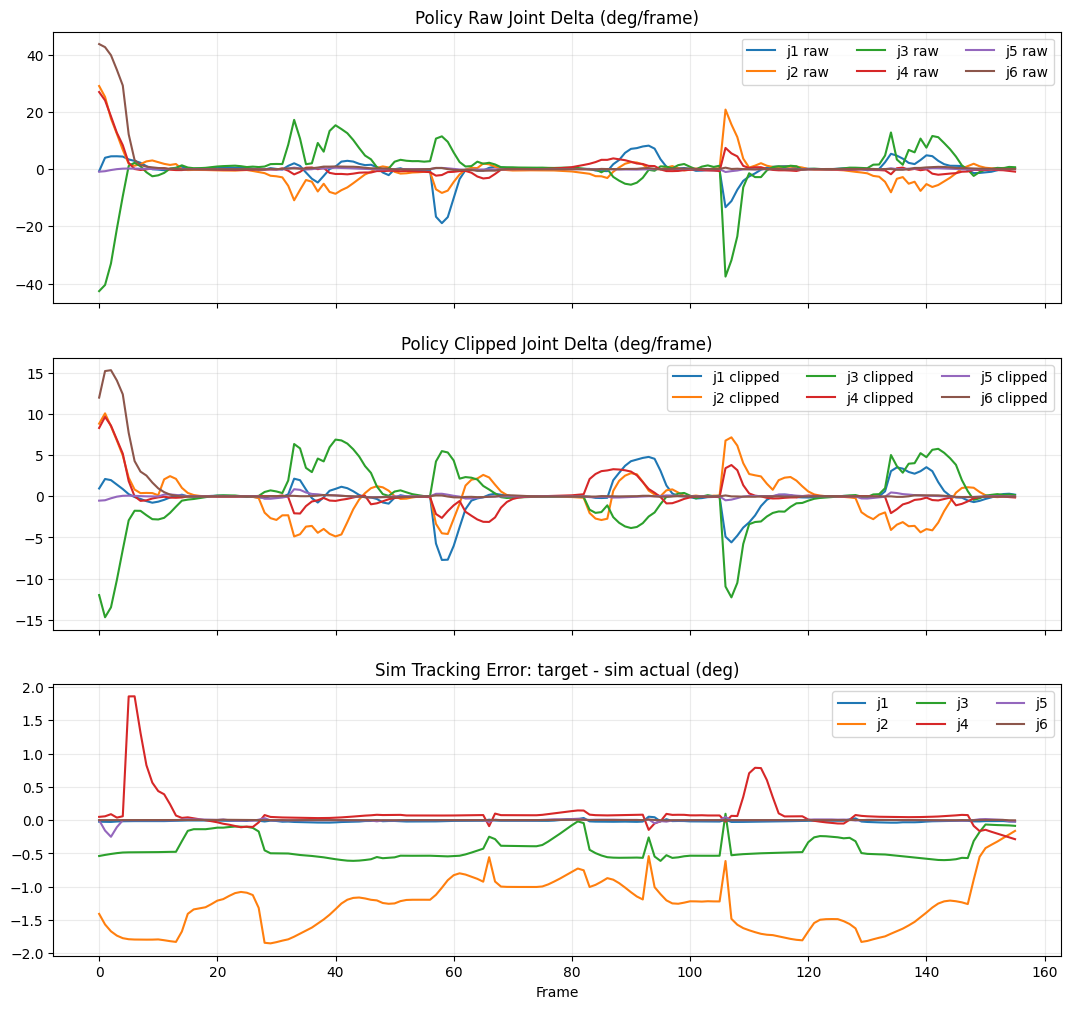

In [48]:
fig, axes = plt.subplots(3, 1, figsize=(13, 12), sharex=True)
for i, name in enumerate(joints):
    axes[0].plot(frame, pred_raw_deg[:, i], label=f'{name} raw')
    axes[1].plot(frame, pred_clip_deg[:, i], label=f'{name} clipped')
    axes[2].plot(frame, q_track_deg[:, i], label=f'{name}')
axes[0].set_title('Policy Raw Joint Delta (deg/frame)')
axes[1].set_title('Policy Clipped Joint Delta (deg/frame)')
axes[2].set_title('Sim Tracking Error: target - sim actual (deg)')
for ax in axes:
    ax.grid(True, alpha=0.25)
    ax.legend(ncol=3)
axes[-1].set_xlabel('Frame')
plt.show()

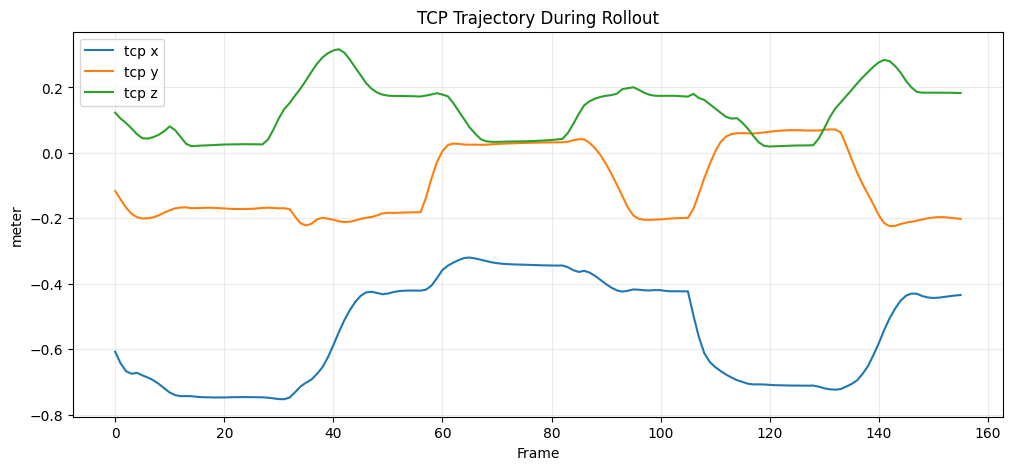

In [49]:
plt.figure(figsize=(12, 5))
plt.plot(frame, tcp[:, 0], label='tcp x')
plt.plot(frame, tcp[:, 1], label='tcp y')
plt.plot(frame, tcp[:, 2], label='tcp z')
plt.title('TCP Trajectory During Rollout')
plt.xlabel('Frame')
plt.ylabel('meter')
plt.grid(True, alpha=0.25)
plt.legend()
plt.show()

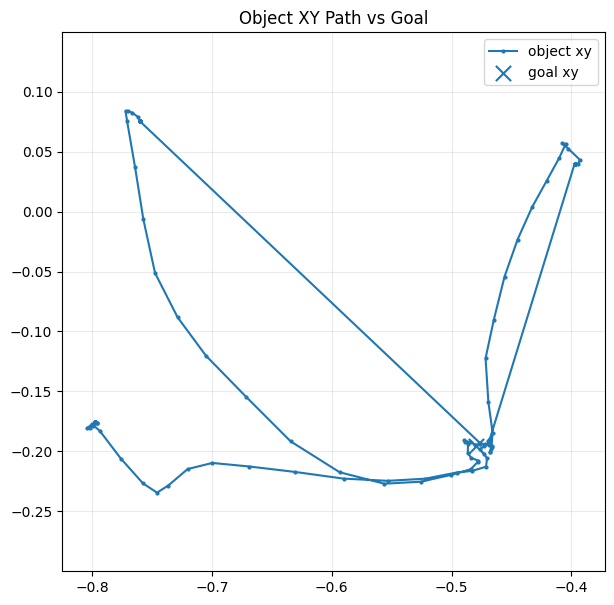

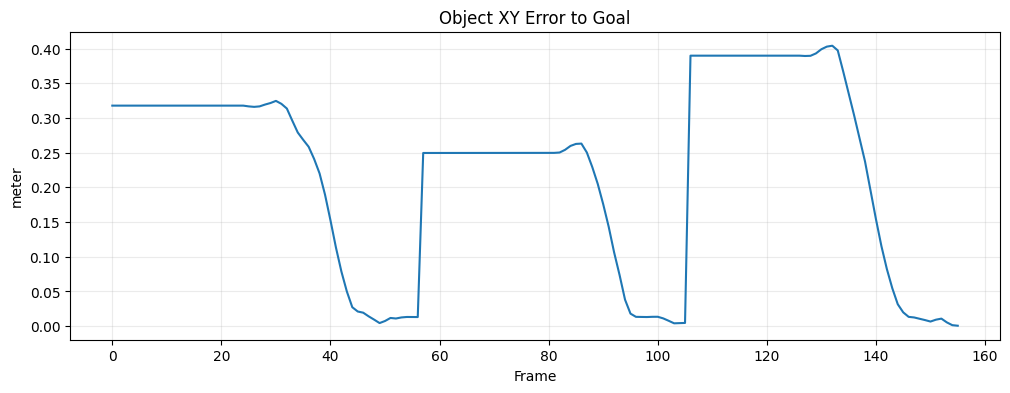

In [50]:
if 'object_pos' in data.files:
    obj = np.asarray(data['object_pos'], dtype=np.float64)
    goal = np.asarray(data['goal_pos'], dtype=np.float64)
    err = np.asarray(data['object_goal_error_xy'], dtype=np.float64)
    plt.figure(figsize=(7, 7))
    plt.plot(obj[:, 0], obj[:, 1], '-o', markersize=2, label='object xy')
    plt.scatter([goal[-1, 0]], [goal[-1, 1]], s=120, marker='x', label='goal xy')
    plt.axis('equal')
    plt.grid(True, alpha=0.25)
    plt.legend()
    plt.title('Object XY Path vs Goal')
    plt.show()

    plt.figure(figsize=(12, 4))
    plt.plot(frame, err)
    plt.title('Object XY Error to Goal')
    plt.xlabel('Frame')
    plt.ylabel('meter')
    plt.grid(True, alpha=0.25)
    plt.show()
else:
    print('这条不是 simtask 日志，没有 object_pos/goal_pos。')